# 실험 전 데이터로 표본을 절약하는 법

**질문**: 표본을 늘리지 않고 더 작은 효과를 감지할 수 있는가?

**결론**: 실험 전 기간의 같은 지표를 공변량으로 쓰면 분산이 크게 준다.
아래 실험에서 표준편차가 6,406 → 3,021로 줄었고, p값이 0.0713에서
0.0039로 떨어져 결론이 뒤집혔다. 같은 데이터, 같은 실험이다.

다른 노트북들이 위양성(없는 차이를 있다고 하는 것)을 다뤘다면,
이 노트북은 반대 방향이다. **있는 차이를 놓치는 문제**를 다룬다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

from abtest_lab.variance import apply_cuped

## 1. 왜 노이즈를 줄여야 하는가

감지하려는 차이와 필요 표본은 제곱 관계에 있다. MDE를 절반으로
줄이면 표본은 약 4배가 필요하다. 작은 효과를 검증하는 일이
원리적으로 비싼 이유다.

표본을 늘리는 것 말고 다른 길이 있다. **노이즈를 줄이는 것**이다.

매출 지표를 생각해보자. 실험 중 매출이 큰 사용자는 실험 전에도
컸을 가능성이 높다. 그 부분은 처치 효과가 아니라 **원래의 성향**이다.
이를 제거하면 남는 변동이 처치 효과에 가까워진다.

In [2]:
rng = np.random.default_rng(seed=2026)
n = 2000

# 실험 전 매출: 소수가 큰 금액을 쓰는 치우친 분포
pre = rng.gamma(shape=2, scale=5000, size=n)

group = rng.choice(["A", "B"], size=n)
noise = rng.normal(0, 3000, size=n)
effect = np.where(group == "B", 400, 0)   # B에만 400원의 진짜 효과

post = pre * 0.8 + noise + effect + 2000
post = np.maximum(post, 0)

df = pd.DataFrame({"group": group, "pre": pre, "post": post})
df.head()

,group,pre,post
0,A,4190.589882,9665.408783
1,A,1107.836851,938.871903
2,B,13169.844960,10276.956646
3,A,6477.541927,6070.473959
4,B,6722.246267,10775.578352


진짜 효과를 **400원**으로 설정했다. 이것을 잡아낼 수 있는지가 시험이다.

`post = pre * 0.8 + ...`로 실험 전 매출에 크게 의존하도록 만들었다.
실제 서비스도 그렇다. 지난달 많이 산 사람이 이번 달에도 많이 산다.

## 2. 보정 없이 검정하면

전환율 같은 비율 지표에는 z검정을 쓰지만, 매출처럼 연속적인 값에는
t검정을 쓴다.

CUPED 적용 전후를 같은 셀에서 계산한다. 셀을 나누면 그 사이에
데이터가 바뀔 수 있다.

In [3]:
post_adj, theta = apply_cuped(df["post"].values, df["pre"].values)
df["post_adj"] = post_adj

a = df[df["group"] == "A"]
b = df[df["group"] == "B"]

rows = []
for col, label in [("post", "보정 전"), ("post_adj", "CUPED")]:
    t, p = ttest_ind(b[col], a[col])
    rows.append({
        "구분": label,
        "관측 차이": round(b[col].mean() - a[col].mean(), 1),
        "표준편차": round(df[col].std(), 1),
        "p값": round(p, 4),
    })

pd.DataFrame(rows)

,구분,관측 차이,표준편차,p값
0,보정 전,517.0,6405.7,0.0713
1,CUPED,389.7,3021.1,0.0039


## 3. 무슨 일이 일어났나

세 가지가 동시에 일어났다.

**① p값이 18배 작아졌다.** 0.0713에서 0.0039로. 0.05를 못 넘던
결과가 명확히 유의해졌다.

**② 추정값이 더 정확해졌다.** 진짜 효과 400원에 대해 517원 → 389.7원.
보정 전 517원에는 배정 불균형에서 온 117원이 섞여 있었다.
노이즈를 줄이면서 우연한 배정 편차까지 일부 걷어낸 결과다.

**③ 평균은 유지됐다.** 줄인 것은 편차이지 수준이 아니다.
"평균 매출 10,229원"이라는 해석이 그대로 유지된다.

보정 계수 theta는 다음과 같이 추정됐다.

In [4]:
print("theta:", round(theta, 3))
print("평균:", round(post.mean(), 1), "→", round(post_adj.mean(), 1))
print("표준편차:", round(post.std(), 1), "→", round(post_adj.std(), 1))

ratio = post_adj.std() / post.std()
print(f"\n분산 비율: {ratio**2:.3f}  →  표본의 {ratio**2:.0%}로 같은 정밀도")

theta: 0.807
평균: 10229.1 → 10229.1
표준편차: 6404.1 → 3020.4

분산 비율: 0.222  →  표본의 22%로 같은 정밀도


theta 0.807은 데이터 생성 시 설정한 0.8과 거의 일치한다.

표준편차가 절반이 되면 분산은 4분의 1이 된다. 표본과 정밀도는
제곱 관계이므로, **같은 정밀도를 얻는 데 표본의 22%면 충분하다**는 뜻이다.
2,000명으로 9,000명 규모의 실험을 한 셈이다.

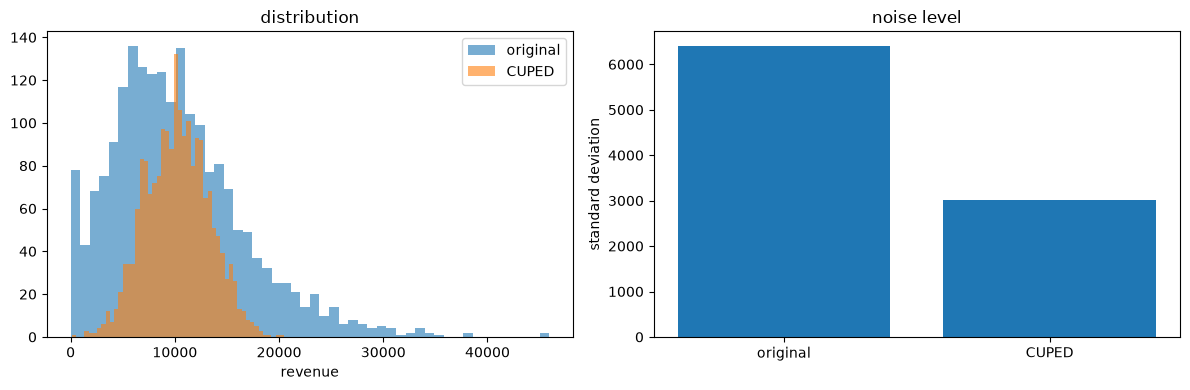

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["post"], bins=50, alpha=0.6, label="original")
axes[0].hist(df["post_adj"], bins=50, alpha=0.6, label="CUPED")
axes[0].set_xlabel("revenue")
axes[0].set_title("distribution")
axes[0].legend()

axes[1].bar(["original", "CUPED"], [df["post"].std(), df["post_adj"].std()])
axes[1].set_ylabel("standard deviation")
axes[1].set_title("noise level")

plt.tight_layout()
plt.show()

왼쪽에서 분포의 폭이 좁아진 것이, 오른쪽에서 그 크기가 절반이라는 것이
보인다. 중심 위치는 그대로다.

## 4. 결론이 뒤집혔다

- 보정 전: p=0.0713 → **"유의하지 않음. 효과 없음"**
- CUPED: p=0.0039 → **"유의함. 약 390원 개선"**

같은 데이터, 같은 실험이다. 없던 효과를 만든 것이 아니라
원래 있던 400원짜리 효과가 노이즈에 묻혀 있다가 드러난 것이다.

보정 전이었다면 "효과 없음"으로 결론 내고 좋은 기능을 버렸을 상황이다.

다른 노트북들이 다룬 위양성(1종 오류)과 반대로, 이것은
**진짜 효과를 놓치는 문제**(2종 오류)다. 위양성만 경계하면
이쪽을 놓치게 된다.

## 5. 쓸 때 주의할 점

**공변량은 반드시 실험 시작 전 기간의 값이어야 한다.**
실험 중 데이터를 쓰면 처치 효과 자체를 빼버린다. 가장 흔한 오용이다.

**theta가 작으면 효과도 작다.**
공변량과 지표가 무관하면 theta가 0에 가까워져 보정이 거의 일어나지
않는다. 쓸모없는 공변량을 넣어도 손해는 없지만 이득도 없다.
안전장치가 내장된 셈이다.

**이 예시는 CUPED에 유리한 조건이다.**
`post = pre * 0.8 + ...`로 의존성을 강하게 설정했다.
실제 서비스에서는 20~50% 분산 감소가 일반적이며,
그래도 표본 20~30% 절감에 해당한다.

같은 지표의 직전 기간 값을 쓰는 것이 보통 가장 잘 작동한다.